# Анализ поисковых запросов

Дескриптивный EDA по колонке `query` датасета «Самокат» (пары «запрос — товар»
с разметкой релевантности ESCI). Здесь смотрим **только на сами запросы** —
без меток релевантности, товаров и опечаток (опечатки разбираются отдельно в `../typos/`).

**Структура:**
1. Базовая статистика — сколько запросов, как они повторяются, какой они длины
2. Что ищут люди — частотный словарь и устойчивые словосочетания
3. Кунсткамера запросов — подборка смешного и странного (`funny_queries.txt`)

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH: str = "../DATA.csv"
TOKEN_RE: re.Pattern[str] = re.compile(r"[а-яёa-z]+")

df: pd.DataFrame = pd.read_csv(DATA_PATH)
queries: pd.Series = pd.Series(df["query"].unique(), name="query")

print(f"Строк в датасете:      {len(df):>6}")
print(f"Уникальных запросов:   {len(queries):>6}")

Строк в датасете:       79774
Уникальных запросов:     9496


## 1. Базовая статистика

### Почему запросов в 8 раз меньше, чем строк

Датасет устроен как **pairwise-разметка** (схема ESCI, как в Amazon Shopping Queries):
под каждый запрос набирается пул товаров-кандидатов из поисковой выдачи, и асессор
размечает каждую пару «запрос — товар» отдельно. Поэтому один запрос встречается
в датасете столько раз, сколько товаров под него разметили — это не дубли
и не повторные вводы пользователей.

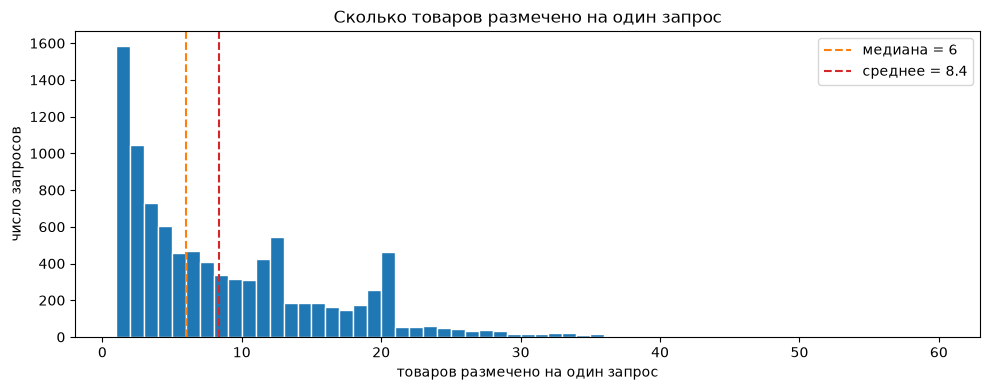

От 1 до 59 товаров на запрос, дисперсия 53.9


In [2]:
items_per_query: pd.Series = df.groupby("query").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(items_per_query, bins=range(1, items_per_query.max() + 2), edgecolor="white")
ax.axvline(items_per_query.median(), color="tab:orange", ls="--",
           label=f"медиана = {items_per_query.median():.0f}")
ax.axvline(items_per_query.mean(), color="tab:red", ls="--",
           label=f"среднее = {items_per_query.mean():.1f}")
ax.set_xlabel("товаров размечено на один запрос")
ax.set_ylabel("число запросов")
ax.set_title("Сколько товаров размечено на один запрос")
ax.legend()
plt.tight_layout()
plt.show()

print(f"От {items_per_query.min()} до {items_per_query.max()} товаров на запрос, "
      f"дисперсия {items_per_query.var():.1f}")

Разброс большой: чаще всего под запрос размечен **один** товар,
но у топ-10% запросов — по 20+ товаров. Горбик на 11–12 товарах намекает,
что для части запросов размечали фиксированную страницу выдачи (~12 позиций).

### Длина запросов

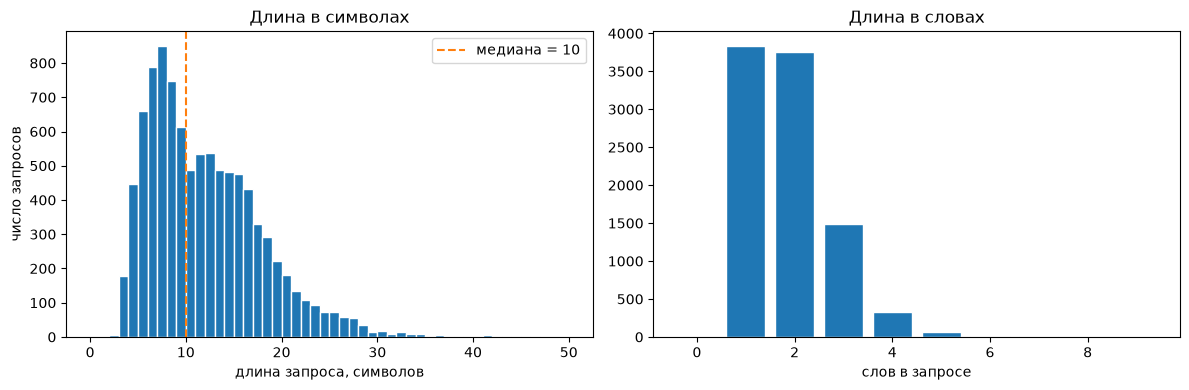

Запросы из 1–2 слов: 80%


In [3]:
char_len: pd.Series = queries.str.len()
word_cnt: pd.Series = queries.str.findall(TOKEN_RE).str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_len, bins=range(0, char_len.max() + 2), edgecolor="white")
axes[0].axvline(char_len.median(), color="tab:orange", ls="--",
                label=f"медиана = {char_len.median():.0f}")
axes[0].set_xlabel("длина запроса, символов")
axes[0].set_ylabel("число запросов")
axes[0].set_title("Длина в символах")
axes[0].legend()

word_dist = word_cnt.value_counts().sort_index()
axes[1].bar(word_dist.index, word_dist.values, edgecolor="white")
axes[1].set_xlabel("слов в запросе")
axes[1].set_title("Длина в словах")
plt.tight_layout()
plt.show()

share_1_2 = word_cnt.isin([1, 2]).mean()
print(f"Запросы из 1–2 слов: {share_1_2:.0%}")

Типичный запрос короткий: медиана 10 символов, 80% запросов — одно или два слова.
Это обычная картина для поиска в приложении доставки: пользователь набирает
название продукта, а не фразу.

### Крайности: самые короткие и самые длинные

In [4]:
by_len = char_len.sort_values()
shortest: pd.DataFrame = pd.DataFrame({
    "запрос": queries[by_len.index[:10]].values,
    "символов": by_len.values[:10],
})
longest: pd.DataFrame = pd.DataFrame({
    "запрос": queries[by_len.index[-10:][::-1]].values,
    "символов": by_len.values[-10:][::-1],
})
display(shortest)
display(longest)

,запрос,символов
0,де,2
1,ци,2
2,d3,2
3,фо,2
4,a4,2
5,dr,2
6,бан,3
7,юту,3
8,свр,3
9,эне,3


,запрос,символов
0,"энергетик wk up, без сахара, малина и мята 0,45 л",49
1,aravia laboratories пенка восстанавливающая с д,47
2,растворимый кофейный напиток monarch раф со вк,46
3,ароматический диффузор aroma harmony белый дуб,46
4,мороженое самокат вафельный стаканчик пломбир,45
5,фарш петелинка премиум из филе куриной грудки,45
6,ароматический спрей для текстиля перец 150 мл,45
7,стейк мираторг black angus пиканья мраморная,44
8,чипсы lay s stax нежная сметана и лук 140 г,43
9,маска майонезная шляпка для смазывания пена,43


Короткие запросы — в основном оборванные начала слов («фо», «эне», «бан»)
и коды («d3», «a4»). Самые длинные подозрительно похожи на **названия товаров
из каталога**, вставленные в поиск целиком («энергетик wk up, без сахара, малина
и мята 0,45 л») — вероятно, скопированы или введены через повторный заказ.

## 2. Что ищут люди

Считаем частоты по **уникальным запросам** (не по строкам), чтобы запросы
с большим пулом размеченных товаров не искажали картину. Служебные слова
(предлоги, союзы) из топа убираем — но не из биграмм, где они содержательны
(«без сахара», «для волос»).

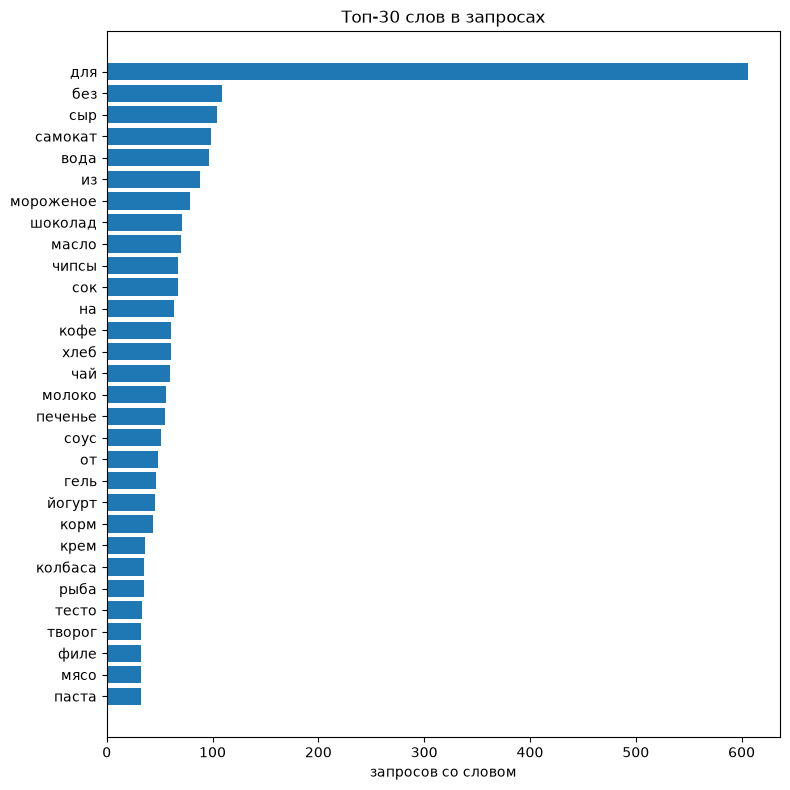

In [5]:
from collections import Counter

# STOPWORDS: frozenset[str] = frozenset(
    # "для без из на от с в и по не под до у к о".split()
# )
STOPWORDS: frozenset[str] = frozenset()
TOP_WORDS: int = 30

tokens: list[list[str]] = queries.str.findall(TOKEN_RE).tolist()
word_freq: Counter[str] = Counter(
    w for ts in tokens for w in ts if len(w) >= 2 and w not in STOPWORDS
)

top = pd.Series(dict(word_freq.most_common(TOP_WORDS)))
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top.index[::-1], top.values[::-1])
ax.set_xlabel("запросов со словом")
ax.set_title(f"Топ-{TOP_WORDS} слов в запросах")
plt.tight_layout()
plt.show()

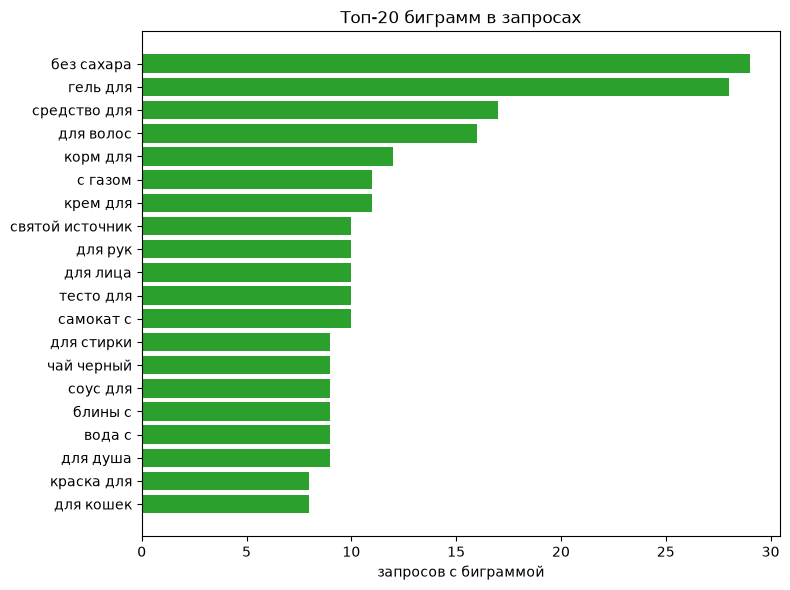

In [6]:
TOP_BIGRAMS: int = 20

bigram_freq: Counter[str] = Counter(
    " ".join(ts[i : i + 2]) for ts in tokens for i in range(len(ts) - 1)
)

top_bi = pd.Series(dict(bigram_freq.most_common(TOP_BIGRAMS)))
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_bi.index[::-1], top_bi.values[::-1], color="tab:green")
ax.set_xlabel("запросов с биграммой")
ax.set_title(f"Топ-{TOP_BIGRAMS} биграмм в запросах")
plt.tight_layout()
plt.show()

## 3. Кунсткамера запросов — смешное и странное

Помимо количественной статистики, в запросах много **человеческого**: опечатки-перлы,
крики души и абсурдные сочетания. Такие запросы — не только повод улыбнуться, но и
полезный материал: кандидаты в «мусорные»/нетипичные запросы (направление 1 из ТЗ).

**Важно про критерий.** «Самокат» — не только еда, а широкий магазин у дома
(техника, косметика, дрогери, инструменты, зоотовары). Поэтому «непродуктовое»
само по себе НЕ смешно — это обычный ассортимент. В подборку берём только то,
где юмор в **языковой форме** (перл-опечатка, слипшиеся слова, крик души вместо
запроса) или в **семантическом абсурде/неуместности** (пояс верности, «человек
бензопила», «стоячий шоколад»).

Подборку собрали **шесть независимых агентов** с высокой планкой: 9 496 уникальных
запросов разбили на равные части, каждый агент вычитал свою. Результаты объединили,
дедуплицировали и **сверили с датасетом** (отбросили искажённые агентами формы).
Итог — в `funny_queries.txt` рядом с ноутбуком.


In [7]:
from pathlib import Path

FUNNY_PATH: Path = Path("funny_queries.txt")

# запросы из подборки идут с отступом и суффиксом [×N] — вытащим сам текст запроса
funny: list[str] = []
for line in FUNNY_PATH.read_text(encoding="utf-8").splitlines():
    if line.startswith("  ") and "[×" in line:
        funny.append(line.strip().rsplit("    [×", 1)[0])

in_data: pd.Series = pd.Series(funny).isin(set(df["query"]))
print(f"Запросов в подборке:        {len(funny):>4}")
print(f"Все есть в датасете:        {in_data.all()}")
print(f"Доля от уникальных запросов: {len(funny) / len(queries):.1%}")

print("\nСлучайные 15 из подборки:")
for q in pd.Series(funny).sample(15, random_state=42):
    print("  •", q)


Запросов в подборке:         145
Все есть в датасете:        True
Доля от уникальных запросов: 1.5%

Случайные 15 из подборки:
  • лягушачьи ланки
  • парашру
  • съела
  • полиморфизм
  • самый богатый человек в вавилоне
  • свитлогорье догорите
  • круготесы
  • наша птичка
  • огурец здесь
  • чучело
  • допинг
  • персидская ночь
  • псыж
  • маршал красотка
  • мега сырище


Тематически подборка распадается на узнаваемые группы: **«явно не Самокат»**
(пояс верности, антисекс), **крики души** («что делать если», «наполеон имел»),
**абсурдные сочетания** («стоячий шоколад», «сок для макаки») и **опечатки-перлы**
(«чемнокодавилка», «попокорм», «антипыпыль»). Часть таких запросов ещё и частотна
(«хорошая девочка черная кровь» — 36 строк разметки), то есть это устойчивый
паттерн, а не единичный ввод — хороший стартовый набор классов для будущего
классификатора «нетипичных» запросов.


### Облако смешных запросов (для презентации)

Чисто ради веселья: облако, где каждый запрос — **целая фраза** (чтобы «пояс верности»
и «человек бензопила» не рассыпались на слова), а размер — по частоте `×N` в разметке.
Картинка сохраняется в `funny_wordcloud.png`.


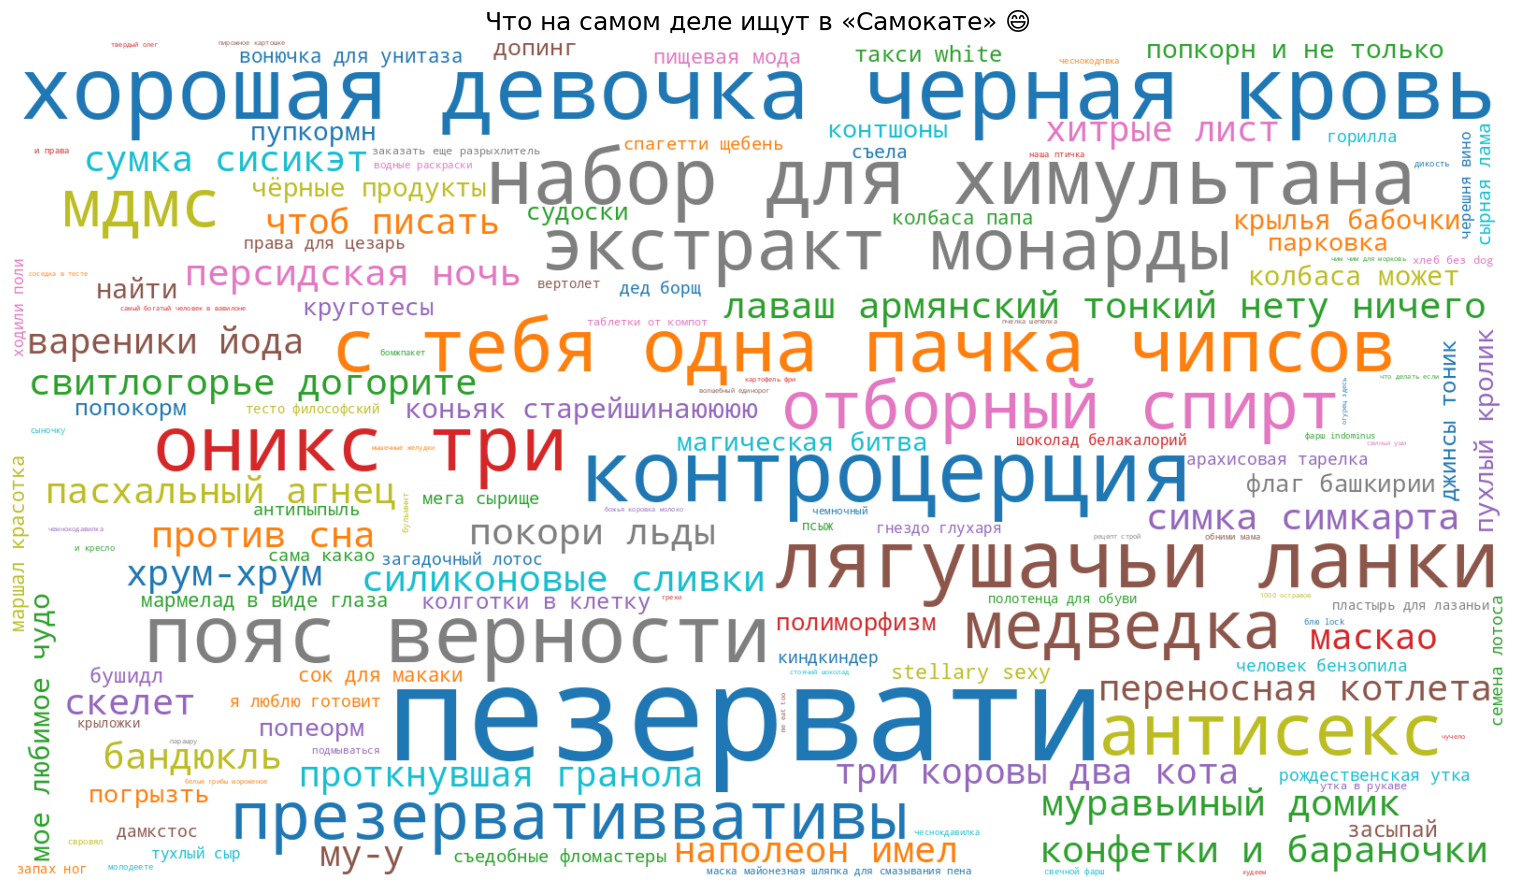

In [8]:
from pathlib import Path
import re
from wordcloud import WordCloud

# частота запроса в разметке — размер слова в облаке
query_counts: dict[str, int] = df["query"].value_counts().to_dict()

EMOJI_RE: re.Pattern[str] = re.compile(r"[^\w\s\-]", re.UNICODE)  # шрифт не рисует эмодзи
freqs: dict[str, int] = {}
for line in Path("funny_queries.txt").read_text(encoding="utf-8").splitlines():
    if line.startswith("  ") and "[×" in line:
        q = line.strip().rsplit("    [×", 1)[0]
        clean = EMOJI_RE.sub("", q).strip()
        if clean:
            freqs[clean] = query_counts.get(q, 1)

wc = WordCloud(
    width=1600, height=900, background_color="white",
    colormap="tab10", prefer_horizontal=0.9,
    collocations=False, random_state=42, margin=6,
).generate_from_frequencies(freqs)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Что на самом деле ищут в «Самокате» 😄", fontsize=18)
plt.tight_layout()
wc.to_file("funny_wordcloud.png")
plt.show()


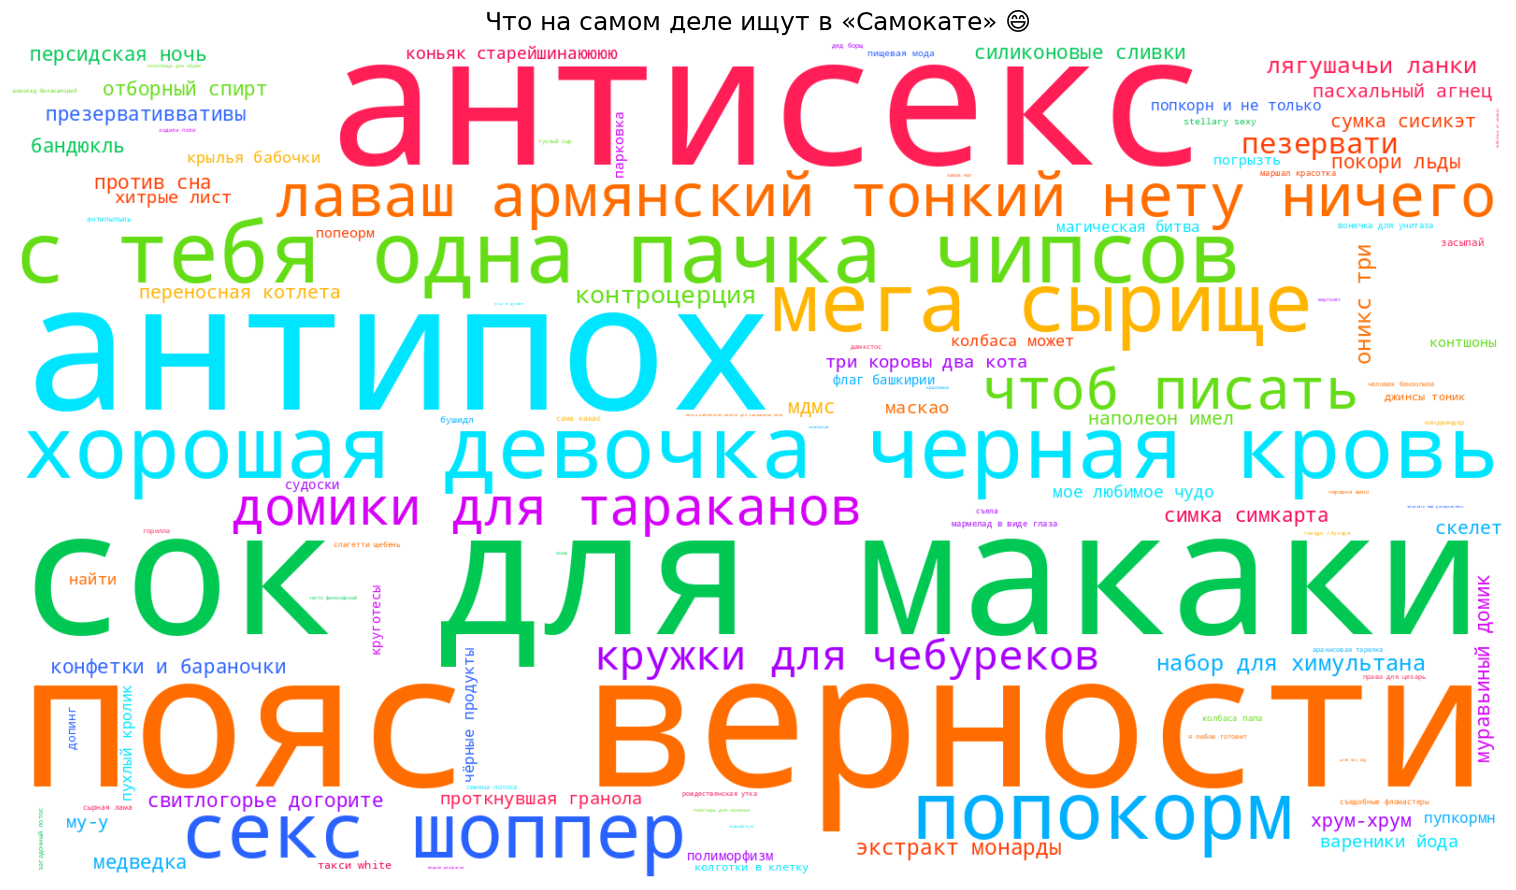

In [9]:
# --- Облако с ручным топом смешных ---
# Запросы из FUNNY_TOP всегда крупнее всех (порядок списка = «смешнота»:
# первый — самый большой). Остальные из подборки — по реальной частоте ×N.
import random
import re
from pathlib import Path
from wordcloud import WordCloud

FUNNY_TOP: list[str] = [
    "пояс верности",
    "антисекс",
    "антипох",
    "сок для макаки",
    "хорошая девочка черная кровь",
    "с тебя одна пачка чипсов",
    "мега сырище",
    "попокорм",
    "секс шоппер",
    "лаваш армянский тонкий нету ничего",
    "чтоб писать",
    "домики для тараканов",
    "кружки для чебуреков",
]

# множители веса для приоритетных: заведомо выше самой частой «обычной» фразы
TOP_HI_MULT: float = 6.0   # вес самого смешного = HI × макс.частота обычных
TOP_LO_MULT: float = 2.5   # вес последнего в списке = LO × макс.частота обычных

# сочная палитра без серо-бежевых — цвета раскидываем по словам случайно
PALETTE: tuple[str, ...] = (
    "#FF1E56", "#FF6D00", "#FFB400", "#00C853", "#00B0FF", "#2962FF",
    "#AA00FF", "#F50057", "#00E5FF", "#64DD17", "#FF3D00", "#D500F9",
)


def color_func(word, font_size, position, orientation, random_state=None, **kwargs) -> str:
    rng = random_state if random_state is not None else random.Random(42)
    return rng.choice(PALETTE)


query_counts: dict[str, int] = df["query"].value_counts().to_dict()
EMOJI_RE: re.Pattern[str] = re.compile(r"[^\w\s\-]", re.UNICODE)  # шрифт не рисует эмодзи


def _clean(q: str) -> str:
    return EMOJI_RE.sub("", q).strip()


# базовые веса — реальная частота запросов из подборки funny_queries.txt
freqs: dict[str, float] = {}
for line in Path("funny_queries.txt").read_text(encoding="utf-8").splitlines():
    if line.startswith("  ") and "[×" in line:
        q = line.strip().rsplit("    [×", 1)[0]
        clean = _clean(q)
        if clean:
            freqs[clean] = float(query_counts.get(q, 1))

# приоритетным — линейно убывающие большие веса поверх реальных частот
top_clean: set[str] = {_clean(q) for q in FUNNY_TOP}
others_max: float = max(
    (v for k, v in freqs.items() if k not in top_clean), default=1.0
)
hi, lo = others_max * TOP_HI_MULT, others_max * TOP_LO_MULT
n: int = len(FUNNY_TOP)
for i, q in enumerate(FUNNY_TOP):
    freqs[_clean(q)] = hi - (hi - lo) * i / (n - 1)

wc = WordCloud(
    width=1600, height=900, background_color="white",
    color_func=color_func, prefer_horizontal=0.9,
    collocations=False, random_state=42, margin=6,
).generate_from_frequencies(freqs)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Что на самом деле ищут в «Самокате» 😄", fontsize=18)
plt.tight_layout()
wc.to_file("funny_wordcloud.png")
plt.show()


## Выводы

- **9 496 уникальных запросов** при 79 774 строках — повторы объясняются
  pairwise-разметкой (в среднем 8,4 товара на запрос, от 1 до 59), а не дублями.
- Типичный запрос — **1–2 слова, ~10 символов**: название продукта, не фраза.
- Лексика подтверждает продуктовую специфику: топ — базовая еда
  (**сыр, вода, мороженое, шоколад, масло, чипсы, сок, кофе, хлеб, чай, молоко**),
  плюс бытовая химия и уход (**гель, крем, корм**).
- Устойчивые биграммы — в основном конструкции с предлогами: **«без сахара»**
  (самая частая — заметный спрос на ЗОЖ), «гель для», «средство для», «для волос»,
  «корм для». Слово **«самокат»** в топе — пользователи ищут товары СТМ по бренду.
- Хвосты распределения длины — сырьё для дальнейшей работы: обрубки
  («фо», «эне») и вставленные целиком названия товаров.- **Кунсткамера (`funny_queries.txt`, 440 запросов, ~4,6%)**: за пределами базовой
  еды пользователи ищут гаджеты, инструменты, товары 18+, атрибутику для анализов —
  и делают это с опечатками-перлами. Многие такие запросы частотны, а не единичны,
  и годятся как размеченное сырьё для классификатора «нетипичных» запросов.
